In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Definir las funciones de activación y entrenamiento
# Función de activación (escalón)
def linear_function(x):
    return x

# Función para hacer predicciones(output)
def adaline_predict(X, weights):
    return linear_function(np.dot(X, weights[1:]) + 0*weights[0])

In [4]:
# Algoritmo del Perceptrón
def adaline_train(X, y, learning_rate, epochs):
    # Inicializar los pesos (uno más para el bias)
    weights = np.random.rand(X.shape[1] + 1)
    #vector de error
    errors = []

    # Entrenamiento
    for _ in range(epochs):
        total_error = 0
        for xi, target in zip(X, y):
            # Calcular la salida (predicción)
            output = adaline_predict(xi,weights)#step_function(np.dot(xi, weights[1:]) + weights[0])
            # Calcular error absoluto
            error = (target - output)**2
            total_error += abs(error)
            # Actualizar los pesos
            update = 2*learning_rate * (target - output)
            weights[1:] += update * xi
            weights[0] += update
        errors.append(total_error)
    return weights,errors

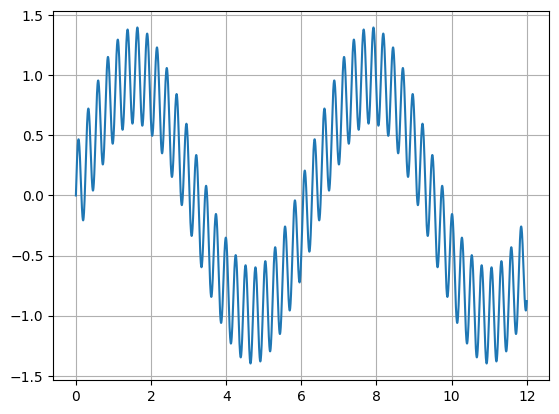

In [5]:
# Preparar los datos de entrada y salida
# Datos de entrada para el filtro adaptativo
#señal con ruido
n_samples = 5000
t = np.linspace(0,12,n_samples)
noise = 0.4*np.sin(24*t)#np.random.normal(0, 0.4, n_samples) #0.4*np.sin(24*t)
X = np.sin(t)+noise
plt.plot(t,X)
plt.grid()

Text(0, 0.5, 'Amplitud de la señal')

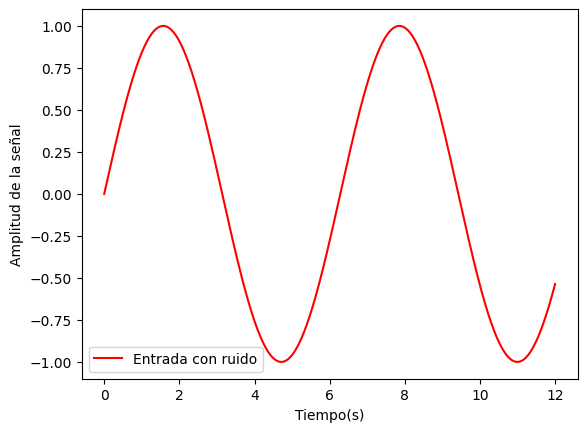

In [6]:
# Salida esperada: señal sin ruido
y = np.sin(t)
plt.plot(t,y,'r')
plt.legend(["Entrada con ruido","Salida sin ruido"])
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")

(4985, 15)
(4985,)
Pesos entrenados: [-1.09794574  4.18773409  2.67481739  1.29696761 -0.42054276 -1.50223259
 -1.96332894 -2.41568581 -2.49031181 -2.90507263 -1.95631559 -1.18902163
 -0.16428948  0.91422254  2.61318674  4.30177494]
Errores: [np.float64(213.43921976679297), np.float64(119.72452452097029), np.float64(116.17443853175807), np.float64(109.43282930222611), np.float64(102.8886225639601), np.float64(96.72689124036012), np.float64(90.9361887869575), np.float64(85.49477208986154), np.float64(80.38156412592872), np.float64(75.57672519559708), np.float64(71.06161415571547), np.float64(66.81871797085279), np.float64(62.83158351986062), np.float64(59.08475341459241), np.float64(55.56370569968523), np.float64(52.25479720486009), np.float64(49.14521032883859), np.float64(46.22290304697695), np.float64(43.47656194729275), np.float64(40.89555811141018), np.float64(38.46990566804262), np.float64(36.190222857099464), np.float64(34.04769545230116), np.float64(32.03404239940553), np.float6

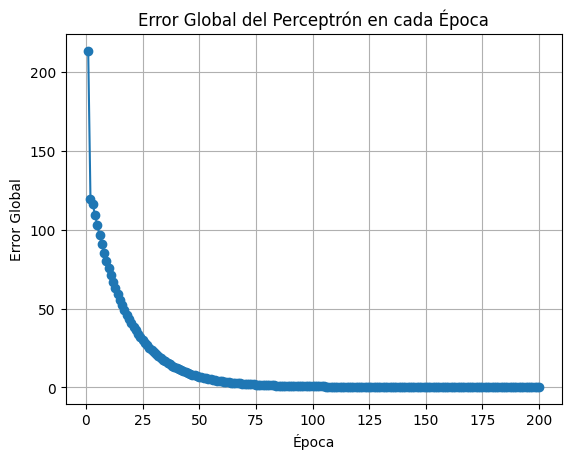

In [7]:
# Crear las entradas y la salida para ADALINE
delay = 15
noisy_signal = np.array([X[i:i+delay] for i in range(n_samples-delay)])
print(noisy_signal.shape)
d = y[delay:]

print(d.shape)


# Entrenar el perceptrón
weights,errors = adaline_train(noisy_signal, d, 0.01, 200)
print("Pesos entrenados:", weights)

print("Errores:", errors)

# Graficar el error global en cada época
plt.figure()
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global del Perceptrón en cada Época')
plt.grid(True)

tamaño  (4985,)
tamaños y  (4985,)


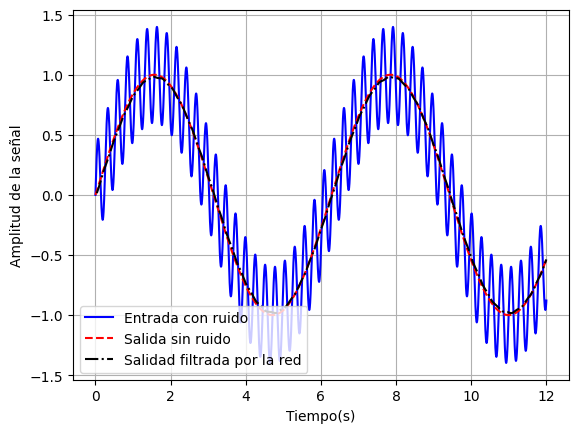

In [8]:
#señal filtrada
prediction=np.zeros(noisy_signal.shape[0])
print("tamaño ", prediction.shape)
i = 0
for xi in noisy_signal:
    #print("prediccion ", i, " ",adaline_predict(xi, weights))
    prediction[i] = adaline_predict(xi, weights)
    i +=1

print("tamaños y ", prediction.shape)
# Mostrar la gráfica
plt.figure()
plt.grid(True)
plt.plot(t,X,'b')
plt.plot(t,y,'--r')
plt.plot(t[delay:],prediction,'-.k')
plt.legend(["Entrada con ruido","Salida sin ruido",'Salidad filtrada por la red'])
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")
plt.show()